# Atividade 2 - Métricas, ROC, AUC e Features

In [1]:
# Importação das bibliotecas principais

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import resample

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

np.random.seed(42)

**Explicação da célula anterior**

- `pandas`: usado para carregar e manipular tabelas.
- `numpy`: usado para cálculos numéricos.
- `matplotlib.pyplot`: usado para criar gráficos.
- `train_test_split`: separa dados em treino e teste.
- `StratifiedKFold`: faz validação cruzada preservando a proporção das classes.
- `cross_val_score`: executa validação cruzada.
- `LabelEncoder`: transforma categorias em números.
- `StandardScaler`: aplica padronização Z-score.
- `MinMaxScaler`: aplica normalização Min-Max.
- `Pipeline`: organiza pré-processamento e modelo em uma sequência segura.
- `TfidfVectorizer`: transforma texto em números.
- `KNeighborsClassifier`: classificador KNN.
- `GaussianNB`: Naive Bayes para variáveis contínuas.
- `MultinomialNB`: Naive Bayes para contagens/texto.
- `DecisionTreeClassifier`, `RandomForestClassifier` e `LogisticRegression`: modelos usados na parte do projeto.
- `classification_report`, `confusion_matrix`, `roc_curve` e `auc`: funções de avaliação.



## A - Seleção do dataset de acordo com o tema e aplicação de técnicas de aprendizado de máquina


![Slide 7](slides_comandos/slide_007.png)

![Slide 8](slides_comandos/slide_008.png)

![Slide 9](slides_comandos/slide_009.png)

![Slide 10](slides_comandos/slide_010.png)

## A - Solução

Nesta parte será usado o dataset do projeto: `data/cybersecurity.csv`.

O projeto simula uma tarefa comum em SOC/MDR: classificar incidentes de segurança em categorias como:

- benign
- brute-force
- port-scan
- sql-injection
- xss
- credential-stuffing
- ddos
- command-injection
- exploit-attempt
- c2

Como o dataset enviado possui dados de logs, serão usadas features numéricas e features manuais extraídas de URL, protocolo, portas e volume de bytes.

In [2]:
# Carregamento do dataset do projeto

df_cyber = pd.read_csv("data/cybersecurity.csv")

display(df_cyber.head())
print("Formato do dataset:", df_cyber.shape)
display(df_cyber.info())
display(df_cyber["attack_type"].value_counts())

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


Formato do dataset: (10000, 13)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   timestamp            10000 non-null  str  
 1   src_ip               10000 non-null  str  
 2   dst_ip               10000 non-null  str  
 3   src_port             10000 non-null  int64
 4   dst_port             10000 non-null  int64
 5   protocol             10000 non-null  str  
 6   bytes_sent           10000 non-null  int64
 7   bytes_received       10000 non-null  int64
 8   user_agent           10000 non-null  str  
 9   url                  6768 non-null   str  
 10  is_internal_traffic  10000 non-null  bool 
 11  label                10000 non-null  int64
 12  attack_type          10000 non-null  str  
dtypes: bool(1), int64(5), str(7)
memory usage: 947.4 KB


None

attack_type
benign                 9600
brute-force             108
port-scan                81
sql-injection            64
xss                      34
credential-stuffing      28
ddos                     27
command-injection        26
exploit-attempt          22
c2                       10
Name: count, dtype: int64

**Explicação da célula anterior**

- `pd.read_csv()`: lê o arquivo CSV do dataset.
- `display(df_cyber.head())`: mostra as primeiras linhas.
- `df_cyber.shape`: mostra quantidade de linhas e colunas.
- `df_cyber.info()`: mostra tipos das colunas e valores nulos.
- `value_counts()`: conta quantas amostras existem em cada classe de ataque.



In [3]:
# Criação de features simples para classificação

df_proj = df_cyber.copy()

df_proj["url"] = df_proj["url"].fillna("")
df_proj["user_agent"] = df_proj["user_agent"].fillna("")
df_proj["protocol_cod"] = LabelEncoder().fit_transform(df_proj["protocol"])

df_proj["url_tamanho"] = df_proj["url"].str.len()
df_proj["user_agent_tamanho"] = df_proj["user_agent"].str.len()

df_proj["tem_login"] = df_proj["url"].str.contains("login|auth|owa", case=False, regex=True).astype(int)
df_proj["tem_sql"] = df_proj["url"].str.contains("sql|phpmyadmin|select|union", case=False, regex=True).astype(int)
df_proj["tem_admin"] = df_proj["url"].str.contains("admin|config", case=False, regex=True).astype(int)
df_proj["tem_webmail"] = df_proj["url"].str.contains("webmail|mail", case=False, regex=True).astype(int)
df_proj["porta_web"] = df_proj["dst_port"].isin([80, 443, 8080]).astype(int)
df_proj["porta_banco"] = df_proj["dst_port"].isin([1433, 3306, 5432]).astype(int)

features_projeto = [
    "src_port",
    "dst_port",
    "bytes_sent",
    "bytes_received",
    "is_internal_traffic",
    "protocol_cod",
    "url_tamanho",
    "user_agent_tamanho",
    "tem_login",
    "tem_sql",
    "tem_admin",
    "tem_webmail",
    "porta_web",
    "porta_banco"
]

X_projeto = df_proj[features_projeto].astype(float)
y_projeto = df_proj["attack_type"]

display(X_projeto.head())
display(y_projeto.head())

,src_port,dst_port,bytes_sent,bytes_received,is_internal_traffic,protocol_cod,url_tamanho,user_agent_tamanho,tem_login,tem_sql,tem_admin,tem_webmail,porta_web,porta_banco
0,56377.0,445.0,8029.0,17204.0,0.0,1.0,36.0,111.0,1.0,0.0,0.0,1.0,0.0,0.0
1,51165.0,1433.0,676368.0,2643374.0,0.0,1.0,56.0,111.0,1.0,0.0,0.0,0.0,0.0,1.0
2,14948.0,1433.0,316502.0,38571.0,0.0,1.0,0.0,80.0,0.0,0.0,0.0,0.0,0.0,1.0
3,36097.0,443.0,70933.0,21935.0,0.0,1.0,41.0,111.0,0.0,1.0,1.0,1.0,1.0,0.0
4,445.0,21255.0,12721.0,9939.0,0.0,1.0,47.0,111.0,0.0,0.0,1.0,0.0,0.0,0.0


0    benign
1    benign
2    benign
3    benign
4    benign
Name: attack_type, dtype: str

**Explicação da célula anterior**

- `copy()`: cria uma cópia do dataset original.
- `fillna("")`: substitui valores vazios por texto vazio.
- `LabelEncoder().fit_transform()`: transforma protocolos como TCP, UDP e ICMP em números.
- `str.len()`: calcula tamanho da URL e do user-agent.
- `str.contains()`: verifica se determinadas palavras aparecem na URL.
- `astype(int)`: transforma valores verdadeiro/falso em 1 e 0.
- `isin()`: verifica se a porta pertence a um conjunto específico.
- `features_projeto`: lista das features usadas pelo modelo.
- `X_projeto`: matriz de entrada.
- `y_projeto`: classe que o modelo deve prever.


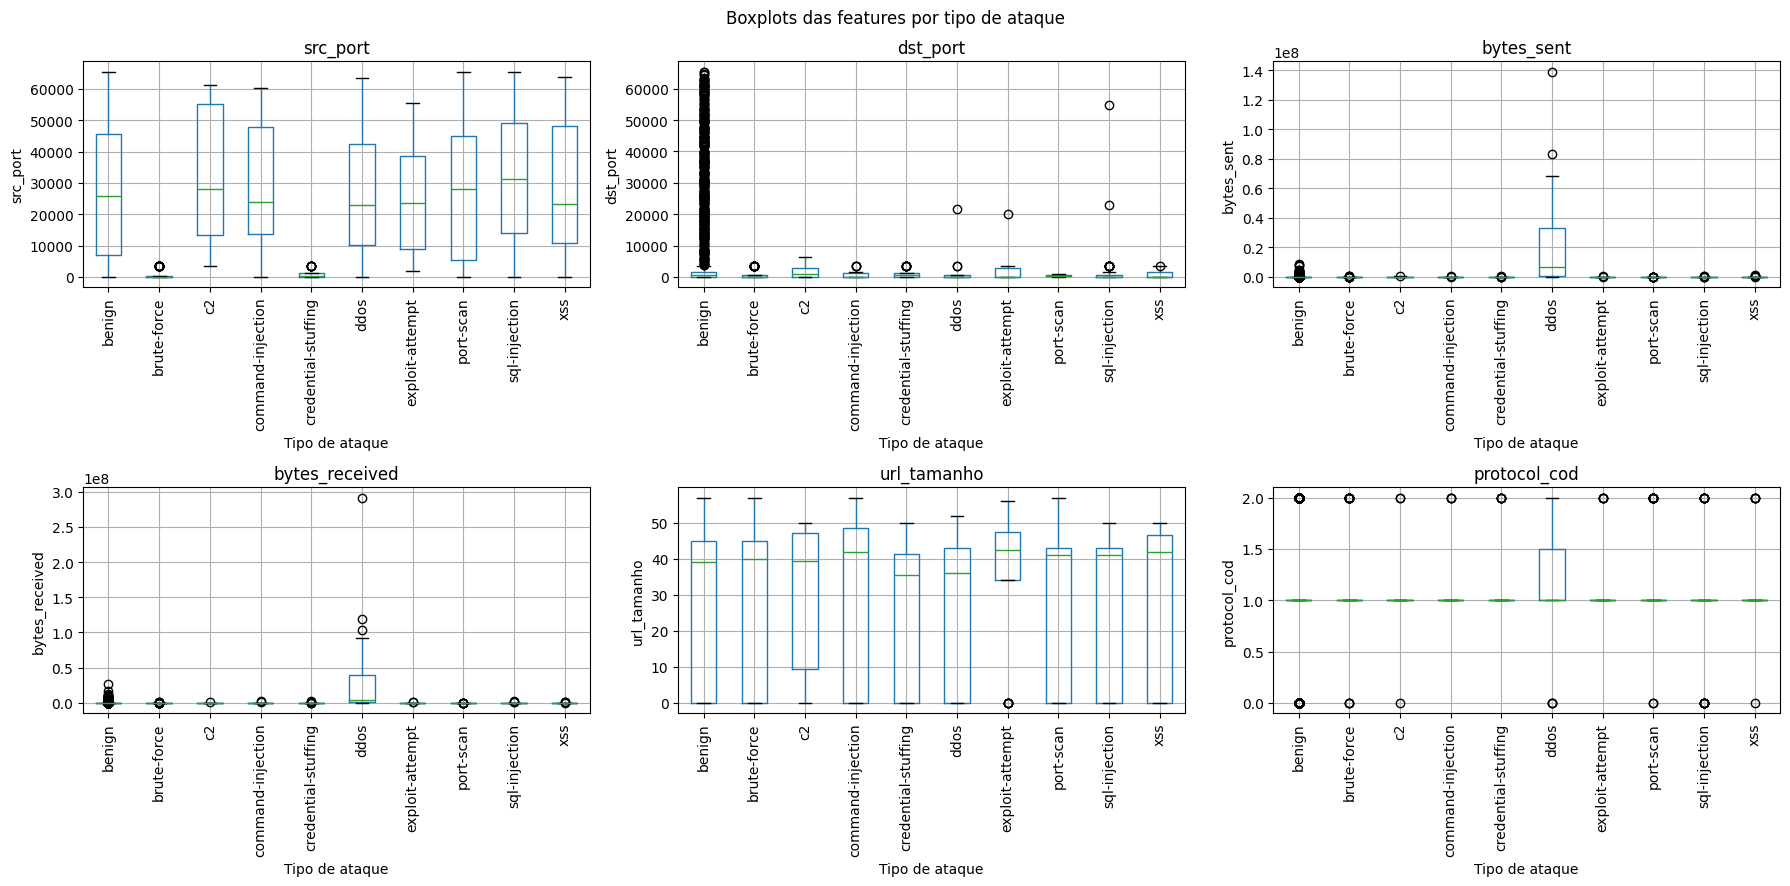

In [4]:
# Boxplots das principais features numéricas

features_boxplot = ["src_port", "dst_port", "bytes_sent", "bytes_received", "url_tamanho", "protocol_cod"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, coluna in zip(axes.ravel(), features_boxplot):
    df_proj.boxplot(column=coluna, by="attack_type", ax=ax)
    ax.set_title(coluna)
    ax.set_xlabel("Tipo de ataque")
    ax.set_ylabel(coluna)
    ax.tick_params(axis="x", rotation=90)

plt.suptitle("Boxplots das features por tipo de ataque")
plt.tight_layout()
plt.show()

**Explicação da célula anterior**

- `features_boxplot`: escolhe as features que serão analisadas graficamente.
- `plt.subplots()`: cria uma grade de gráficos.
- `df_proj.boxplot()`: cria boxplots agrupados pela classe `attack_type`.
- `tick_params(rotation=90)`: gira os nomes das classes para facilitar leitura.
- `plt.tight_layout()`: ajusta o espaçamento dos gráficos.



### A - Análise dos boxplots

Os boxplots mostram que algumas features possuem escalas muito diferentes. `bytes_sent` e `bytes_received`, por exemplo, podem ter valores muito altos em alguns ataques, enquanto features binárias como `tem_login`, `tem_sql` e `porta_web` só assumem valores 0 ou 1.

Essa diferença de escala é importante porque algoritmos baseados em distância, como KNN, podem ser dominados por features com valores maiores. Por isso, a normalização é uma etapa relevante neste problema.

Também é possível observar que algumas classes de ataque são raras. Isso deixa o problema desbalanceado: há muito mais exemplos benignos do que exemplos de ataques. Esse ponto influencia diretamente métricas como acurácia, precision, recall e F1-score.

In [5]:
# Reamostragem simples para reduzir o desbalanceamento

df_modelo = df_proj[features_projeto + ["attack_type"]].copy()

classes = df_modelo["attack_type"].unique()
amostras_por_classe = 80

partes = []

for classe in classes:
    dados_classe = df_modelo[df_modelo["attack_type"] == classe]

    dados_balanceados = resample(
        dados_classe,
        replace=True,
        n_samples=amostras_por_classe,
        random_state=42
    )

    partes.append(dados_balanceados)

df_balanceado = pd.concat(partes).sample(frac=1, random_state=42)

X_bal = df_balanceado[features_projeto].astype(float)
y_bal = df_balanceado["attack_type"]

display(df_balanceado["attack_type"].value_counts())

attack_type
ddos                   80
benign                 80
command-injection      80
xss                    80
credential-stuffing    80
exploit-attempt        80
brute-force            80
c2                     80
sql-injection          80
port-scan              80
Name: count, dtype: int64

**Explicação**

- `df_modelo`: mantém apenas as features e a classe.
- `unique()`: identifica todas as classes existentes.
- `amostras_por_classe = 80`: define uma quantidade igual de amostras por classe.
- `resample()`: faz reamostragem com reposição.
- `pd.concat()`: junta as partes balanceadas.
- `sample(frac=1)`: embaralha o dataset.
- `X_bal`: entrada balanceada.
- `y_bal`: alvo balanceado.


In [6]:
# KNN e Naive Bayes com normalização e 5-fold cross-validation

modelos_a = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "GaussianNB": GaussianNB()
}

preprocessamentos_a = {
    "Sem normalização": None,
    "MinMax": MinMaxScaler(),
    "Z-score": StandardScaler()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_a = []

for nome_prep, prep in preprocessamentos_a.items():
    for nome_modelo, modelo in modelos_a.items():

        if prep is None:
            pipe = Pipeline([("modelo", modelo)])
        else:
            pipe = Pipeline([("preprocessamento", prep), ("modelo", modelo)])

        scores = cross_val_score(pipe, X_bal, y_bal, cv=cv, scoring="accuracy")

        for fold, score in enumerate(scores, start=1):
            resultados_a.append({
                "Preprocessamento": nome_prep,
                "Modelo": nome_modelo,
                "Fold": fold,
                "Acuracia": score
            })

resultados_a_df = pd.DataFrame(resultados_a)

display(resultados_a_df)
display(resultados_a_df.groupby(["Preprocessamento", "Modelo"])["Acuracia"].agg(["mean", "std"]))

,Preprocessamento,Modelo,Fold,Acuracia
0,Sem normalização,KNN,1,0.51875
1,Sem normalização,KNN,2,0.49375
2,Sem normalização,KNN,3,0.59375
3,Sem normalização,KNN,4,0.60000
4,Sem normalização,KNN,5,0.48750
5,Sem normalização,GaussianNB,1,0.26875
6,Sem normalização,GaussianNB,2,0.30000
7,Sem normalização,GaussianNB,3,0.26875
8,Sem normalização,GaussianNB,4,0.26875
9,Sem normalização,GaussianNB,5,0.27500


mean       std
Preprocessamento Modelo                       
MinMax           GaussianNB  0.39000  0.040889
                 KNN         0.58250  0.050852
Sem normalização GaussianNB  0.27625  0.013550
                 KNN         0.53875  0.054379
Z-score          GaussianNB  0.39000  0.040889
                 KNN         0.58250  0.026295

**Explicação da célula anterior**

- `modelos_a`: guarda os dois modelos exigidos, KNN e GaussianNB.
- `preprocessamentos_a`: guarda as estratégias de normalização.
- `StratifiedKFold()`: cria 5 folds mantendo a proporção das classes.
- `Pipeline()`: garante que a normalização seja aplicada corretamente dentro de cada fold.
- `cross_val_score()`: calcula acurácia em cada fold.
- `groupby().agg()`: calcula média e desvio padrão dos resultados.


C:\Users\Murillo\AppData\Local\Temp\ipykernel_26256\1084691568.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_box, labels=labels)


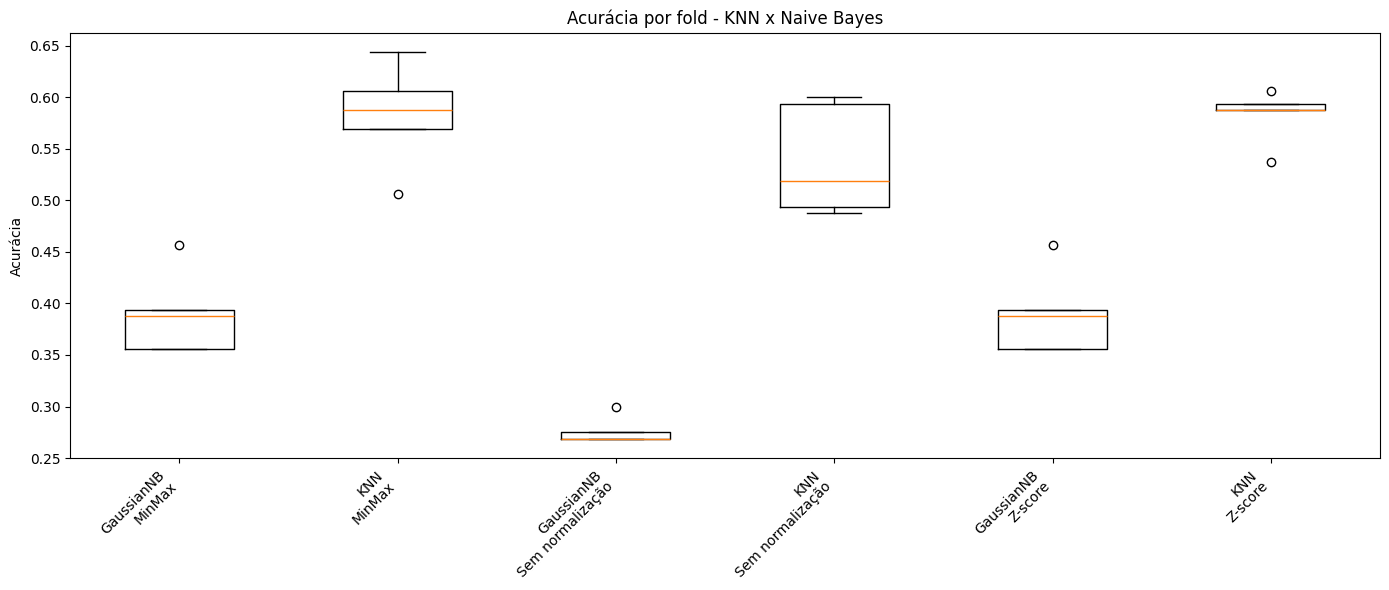

In [7]:
# Boxplot dos resultados de cada fold

labels = []
dados_box = []

for (prep, modelo), grupo in resultados_a_df.groupby(["Preprocessamento", "Modelo"]):
    labels.append(f"{modelo}\n{prep}")
    dados_box.append(grupo["Acuracia"].values)

plt.figure(figsize=(14, 6))
plt.boxplot(dados_box, labels=labels)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Acurácia")
plt.title("Acurácia por fold - KNN x Naive Bayes")
plt.tight_layout()
plt.show()

**Explicação da célula anterior**

- `groupby()`: separa resultados por modelo e pré-processamento.
- `plt.boxplot()`: mostra a distribuição das acurácias nos folds.
- `labels`: nomes exibidos no eixo x.
- `plt.ylabel()`, `plt.title()`: adicionam rótulos e título ao gráfico.



In [8]:
# 5-fold cross-validation executado 10 vezes

resultados_10_a = []

for repeticao in range(1, 11):
    cv_rep = StratifiedKFold(n_splits=5, shuffle=True, random_state=100 + repeticao)

    for nome_prep, prep in preprocessamentos_a.items():
        for nome_modelo, modelo in modelos_a.items():

            if prep is None:
                pipe = Pipeline([("modelo", modelo)])
            else:
                pipe = Pipeline([("preprocessamento", prep), ("modelo", modelo)])

            scores = cross_val_score(pipe, X_bal, y_bal, cv=cv_rep, scoring="accuracy")

            resultados_10_a.append({
                "Repeticao": repeticao,
                "Preprocessamento": nome_prep,
                "Modelo": nome_modelo,
                "Acuracia_media": scores.mean()
            })

resultados_10_a_df = pd.DataFrame(resultados_10_a)

display(resultados_10_a_df)
display(resultados_10_a_df.groupby(["Preprocessamento", "Modelo"])["Acuracia_media"].agg(["mean", "std"]))

,Repeticao,Preprocessamento,Modelo,Acuracia_media
0,1,Sem normalização,KNN,0.53875
1,1,Sem normalização,GaussianNB,0.28875
2,1,MinMax,KNN,0.56875
3,1,MinMax,GaussianNB,0.38500
4,1,Z-score,KNN,0.58500
5,1,Z-score,GaussianNB,0.38500
6,2,Sem normalização,KNN,0.54625
7,2,Sem normalização,GaussianNB,0.25875
8,2,MinMax,KNN,0.57500
9,2,MinMax,GaussianNB,0.39625


mean       std
Preprocessamento Modelo                        
MinMax           GaussianNB  0.389125  0.007242
                 KNN         0.572125  0.009429
Sem normalização GaussianNB  0.278375  0.010509
                 KNN         0.544125  0.007994
Z-score          GaussianNB  0.390250  0.008118
                 KNN         0.581250  0.009129

**Explicação da célula anterior**

- `range(1, 11)`: executa o processo 10 vezes.
- `random_state=100 + repeticao`: muda a divisão dos folds a cada execução.
- `scores.mean()`: calcula a média da acurácia nos 5 folds.
- `resultados_10_a_df`: tabela final com as 10 execuções.


C:\Users\Murillo\AppData\Local\Temp\ipykernel_26256\55273201.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_box, labels=labels)


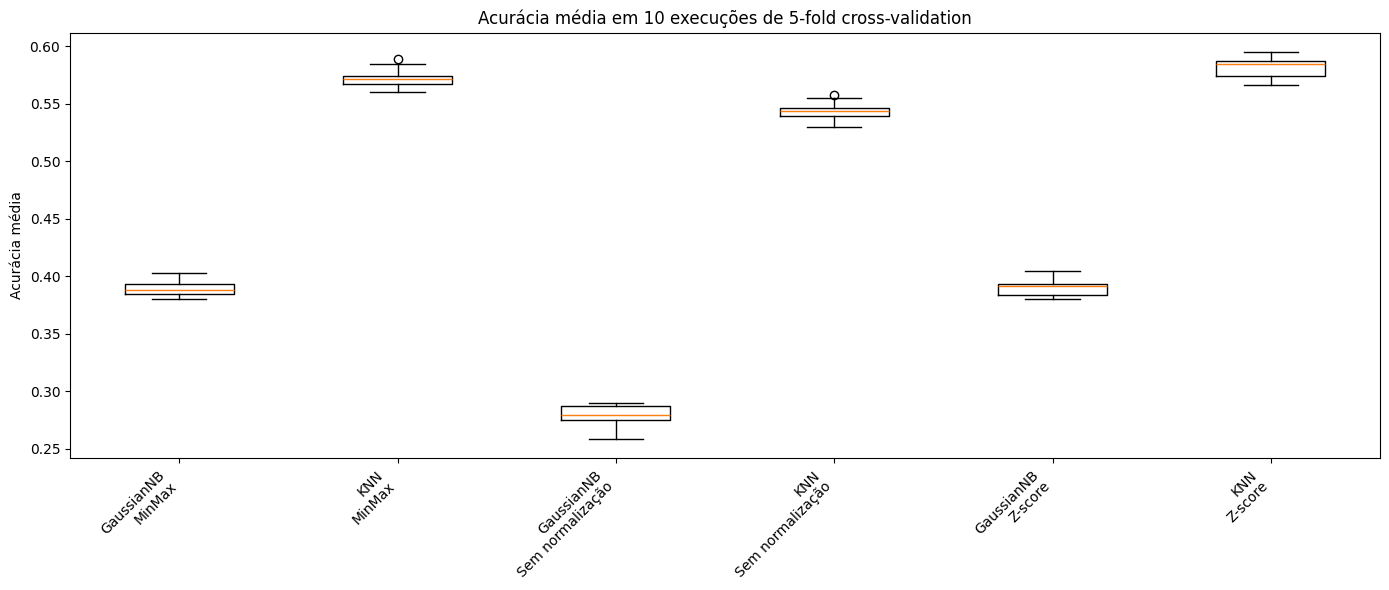

In [9]:
# Boxplot das 10 execuções

labels = []
dados_box = []

for (prep, modelo), grupo in resultados_10_a_df.groupby(["Preprocessamento", "Modelo"]):
    labels.append(f"{modelo}\n{prep}")
    dados_box.append(grupo["Acuracia_media"].values)

plt.figure(figsize=(14, 6))
plt.boxplot(dados_box, labels=labels)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Acurácia média")
plt.title("Acurácia média em 10 execuções de 5-fold cross-validation")
plt.tight_layout()
plt.show()

**Explicação da célula anterior**

- O código monta uma lista de resultados por combinação de modelo e normalização.
- `plt.boxplot()` mostra se o desempenho foi estável nas 10 repetições.
- Quanto menor a dispersão do boxplot, mais estável foi o modelo.


### A - Análise dos resultados e conclusão

O projeto CyberIncident ML usa dados de logs para classificar incidentes de segurança. As classes do dataset são desbalanceadas, com grande predominância de tráfego benigno. Por isso, foi aplicada uma reamostragem simples para deixar o treinamento mais equilibrado.

O KNN tende a ser mais sensível à normalização, porque usa distância entre pontos. Quando as features estão em escalas muito diferentes, variáveis como `bytes_sent` e `bytes_received` podem dominar a decisão. O Gaussian Naive Bayes sofre menos com escala, mas ainda depende da distribuição das features.

Nos boxplots dos folds, a média indica o desempenho típico de cada modelo, enquanto a dispersão mostra estabilidade. Nas 10 execuções, o objetivo é verificar se o resultado se mantém mesmo mudando as divisões dos dados.

**Conclusão da parte A:** o dataset de cibersegurança permite aplicar aprendizado supervisionado em um problema realista de SOC/MDR. A normalização e a reamostragem são importantes para evitar que escala e desbalanceamento prejudiquem a avaliação dos modelos.

## B - Conceitos básicos de aprendizado de máquina


![Slide 11](slides_comandos/slide_011.png)

![Slide 12](slides_comandos/slide_012.png)

![Slide 13](slides_comandos/slide_013.png)

![Slide 14](slides_comandos/slide_014.png)

## B - Solução baseada no arquivo `ch01.ipynb`

Nesta letra, a resposta foi refeita para seguir o que o comando pede: explicar as figuras do arquivo **ch01.ipynb**, e não explicar o projeto de cibersegurança.

O arquivo `ch01.ipynb` pertence ao capítulo **Giving Computers the Ability to Learn from Data** e apresenta conceitos introdutórios de Machine Learning, como:

- transformação de dados em conhecimento;
- aprendizado supervisionado;
- classificação;
- regressão;
- aprendizado por reforço;
- aprendizado não supervisionado;
- clustering;
- redução de dimensionalidade;
- fluxo geral de pré-processamento, treinamento, avaliação e predição.

A seguir, as imagens extraídas do próprio `ch01.ipynb` são apresentadas e explicadas em detalhes.

### Construindo máquinas inteligentes para transformar dados em conhecimento

![Figura 01_01 — Construindo máquinas inteligentes para transformar dados em conhecimento](images_ch01/01_01.png)

**Explicação**

A figura representa a ideia central do Machine Learning: usar dados como entrada para extrair padrões e produzir conhecimento útil. Em vez de programar manualmente todas as regras, o modelo aprende relações a partir dos exemplos. Esse conceito é a base de todo o restante da atividade, pois tanto o Iris quanto o classificador de incidentes dependem de padrões presentes nos dados.



### Os três tipos principais de aprendizado de máquina

![Figura 01_02 — Os três tipos principais de aprendizado de máquina](images_ch01/01_02.png)

**Explicação**

A figura organiza Machine Learning em três grandes famílias: aprendizado supervisionado, aprendizado não supervisionado e aprendizado por reforço. No aprendizado supervisionado, temos dados com respostas conhecidas. No não supervisionado, buscamos estruturas sem rótulos. No aprendizado por reforço, um agente aprende por tentativa e erro com recompensas.



### Classificação para prever rótulos de classe

![Figura 01_03 — Classificação para prever rótulos de classe](images_ch01/01_03.png)

**Explicação**

A figura mostra a tarefa de classificação. Nela, o objetivo é atribuir uma classe a uma nova amostra. Essa é a lógica usada nas questões da atividade: prever espécie do Iris, prever spam ou não spam, prever se uma amostra é versicolor e classificar incidentes de cibersegurança.


### Regressão para prever valores contínuos

![Figura 01_04 — Regressão para prever valores contínuos](images_ch01/01_04.png)

**Explicação**

A figura mostra regressão, que é diferente de classificação. Em regressão, a saída é um valor numérico contínuo, como preço, temperatura ou peso. Embora a atividade trabalhe principalmente com classificação, entender regressão ajuda a compreender a Logistic Regression usada na curva ROC, pois ela gera probabilidades contínuas antes da decisão final.


### Aprendizado por reforço

![Figura 01_05 — Aprendizado por reforço](images_ch01/01_05.png)

**Explicação**

A figura ilustra o aprendizado por reforço, em que um agente interage com um ambiente e recebe recompensas ou punições. Esse tipo de aprendizado não é o foco da atividade, mas ajuda a diferenciar problemas em que existe uma tabela pronta de exemplos rotulados daqueles em que o agente aprende por interação.


### Aprendizado não supervisionado

![Figura 01_06 — Aprendizado não supervisionado](images_ch01/01_06.png)

**Explicação**

A figura apresenta aprendizado não supervisionado, em que não há rótulo de classe. O objetivo é encontrar estrutura nos dados, como grupos naturais. Isso contrasta com as tarefas da atividade, que são supervisionadas porque existe uma classe correta para treinamento e avaliação.


### Clustering para encontrar subgrupos

![Figura 01_07 — Clustering para encontrar subgrupos](images_ch01/01_07.png)

**Explicação**

A figura representa clustering, uma técnica não supervisionada usada para agrupar amostras semelhantes. Em segurança da informação, clustering poderia ser usado para agrupar comportamentos de rede parecidos, mas nesta atividade usamos classificadores supervisionados porque já temos rótulos.


### Redução de dimensionalidade

![Figura 01_08 — Redução de dimensionalidade](images_ch01/01_08.png)

**Explicação**

A figura mostra a ideia de reduzir a quantidade de features mantendo a maior parte da informação importante. Isso é útil quando há muitas variáveis. No projeto de incidentes, por exemplo, texto vetorizado por TF-IDF pode gerar muitas colunas, e técnicas de redução poderiam ser aplicadas em versões mais avançadas.


### Fluxo geral de Machine Learning

![Figura 01_09 — Fluxo geral de Machine Learning](images_ch01/01_09.png)

**Explicação**

A figura resume o fluxo completo: dados brutos passam por pré-processamento, são divididos em treino e teste, alimentam o algoritmo de aprendizado, geram um modelo final, são avaliados e depois usados para predição. Esse fluxo aparece em praticamente todas as partes da atividade.


### B - Análise dos resultados

A letra B não exige treinamento de modelo; ela exige compreensão conceitual. Por isso, a análise aqui se concentra nas figuras do `ch01.ipynb`.

As figuras mostram que Machine Learning é um processo estruturado. Primeiro, os dados precisam ser organizados. Depois, as features precisam representar bem o problema. Em seguida, o modelo é treinado e avaliado. Essa ordem é importante porque um modelo não aprende diretamente conceitos humanos; ele aprende padrões matemáticos nos dados.

O ponto mais importante para a atividade é a diferença entre **features** e **labels**. As features são as entradas do modelo. Os labels são as respostas corretas usadas durante o treinamento supervisionado. No Iris, as features são medidas da flor e o label é a espécie. No projeto de cibersegurança, as features são informações do evento e o label é o tipo de ataque.

Também é importante destacar o papel do pré-processamento. O `ch01.ipynb` mostra que antes de treinar o modelo pode ser necessário transformar, escalar, selecionar ou reduzir features. Isso aparece diretamente nas questões D e E, em que normalização, padronização e escolha de features alteram o desempenho dos classificadores.

Com base no `ch01.ipynb`, a parte B demonstra os fundamentos que sustentam toda a atividade. O notebook mostra que Machine Learning não é apenas aplicar um algoritmo, mas seguir um fluxo: entender os dados, separar features e labels, pré-processar, treinar, avaliar e prever.

Assim, a letra B funciona como a base teórica das demais questões. Ela explica por que os modelos KNN, Naive Bayes, Logistic Regression e Random Forest precisam de dados bem organizados e por que métricas como accuracy, precision, recall, F1-score, ROC e AUC são necessárias para avaliar se o aprendizado realmente funcionou.

## C - Métricas


![Slide 15](slides_comandos/slide_015.png)

![Slide 16](slides_comandos/slide_016.png)

## C - Solução

Nesta parte são apresentadas as métricas:

- Accuracy;
- Precision;
- Recall;
- F1-score.

Para cada métrica, serão usadas duas matrizes de confusão: uma boa e outra problemática.

In [10]:
# Função para calcular métricas a partir de matriz de confusão binária

def calcular_metricas_binarias(cm):
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

    return pd.Series({
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

matriz_boa = np.array([[45, 5], [6, 44]])
matriz_ruim_desbalanceada = np.array([[95, 0], [5, 0]])

display(pd.DataFrame(matriz_boa, index=["Real Negativo", "Real Positivo"], columns=["Predito Negativo", "Predito Positivo"]))
display(calcular_metricas_binarias(matriz_boa).to_frame("Matriz boa"))

display(pd.DataFrame(matriz_ruim_desbalanceada, index=["Real Negativo", "Real Positivo"], columns=["Predito Negativo", "Predito Positivo"]))
display(calcular_metricas_binarias(matriz_ruim_desbalanceada).to_frame("Matriz problemática"))

,Predito Negativo,Predito Positivo
Real Negativo,45,5
Real Positivo,6,44


,Matriz boa
TN,45.000000
FP,5.000000
FN,6.000000
TP,44.000000
Accuracy,0.890000
Precision,0.897959
Recall,0.880000
F1-score,0.888889


,Predito Negativo,Predito Positivo
Real Negativo,95,0
Real Positivo,5,0


,Matriz problemática
TN,95.00
FP,0.00
FN,5.00
TP,0.00
Accuracy,0.95
Precision,0.00
Recall,0.00
F1-score,0.00


**Explicação da célula anterior**

- `calcular_metricas_binarias()`: função que calcula métricas usando uma matriz 2x2.
- `cm.ravel()`: transforma a matriz em quatro valores: TN, FP, FN e TP.
- `accuracy`: proporção total de acertos.
- `precision`: proporção de positivos previstos corretamente.
- `recall`: proporção de positivos reais encontrados.
- `f1`: média harmônica entre precision e recall.
- `pd.DataFrame()`: organiza a matriz em tabela.
- `display()`: exibe as tabelas no notebook.


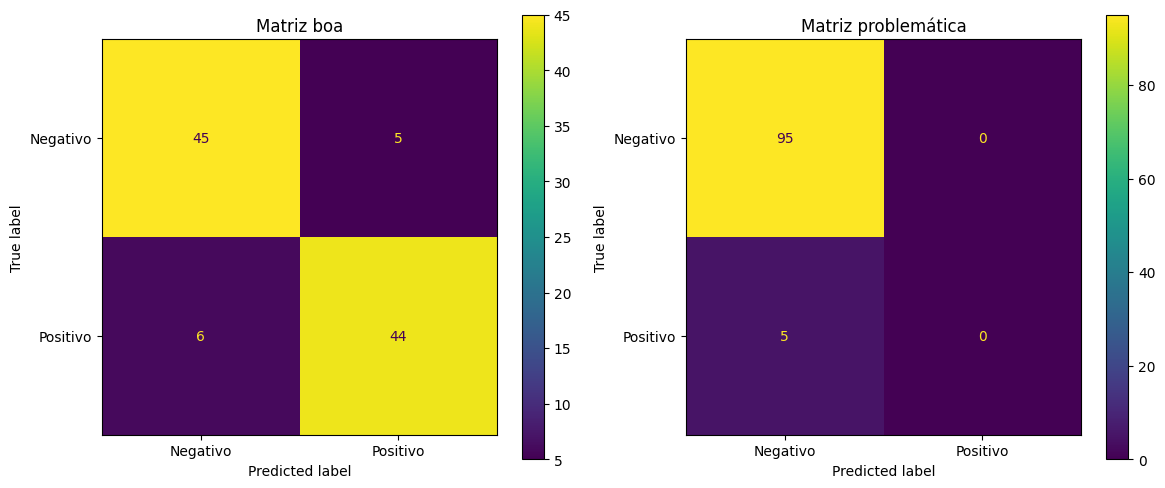

In [11]:
# Gráfico das matrizes de confusão

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(matriz_boa, display_labels=["Negativo", "Positivo"]).plot(ax=axes[0], values_format="d")
axes[0].set_title("Matriz boa")

ConfusionMatrixDisplay(matriz_ruim_desbalanceada, display_labels=["Negativo", "Positivo"]).plot(ax=axes[1], values_format="d")
axes[1].set_title("Matriz problemática")

plt.tight_layout()
plt.show()

**Explicação da célula anterior**

- `plt.subplots()`: cria dois gráficos lado a lado.
- `ConfusionMatrixDisplay()`: prepara a visualização da matriz de confusão.
- `.plot()`: desenha a matriz.
- `values_format="d"`: mostra valores inteiros.
- `set_title()`: define o título de cada gráfico.


### C - Análise dos resultados e conclusão

A matriz boa apresenta equilíbrio entre acertos positivos e negativos. Por isso, accuracy, precision, recall e F1-score ficam altos.

A matriz problemática demonstra a desvantagem da acurácia. O modelo acerta muitos negativos, mas não identifica nenhum positivo. Mesmo assim, a acurácia pode parecer alta por causa do desbalanceamento.

A precision mostra se as previsões positivas são confiáveis. O recall mostra se o modelo consegue encontrar os casos positivos reais. O F1-score equilibra precision e recall.

**Conclusão da parte C:** não se deve avaliar um classificador usando apenas acurácia. Em segurança da informação, falsos negativos podem ser perigosos, pois significam ataques reais não detectados.

## D - Comparando Naive Bayes e KNN com estratégias diferentes de normalização usando Iris


![Slide 17](slides_comandos/slide_017.png)

![Slide 18](slides_comandos/slide_018.png)

![Slide 19](slides_comandos/slide_019.png)

![Slide 20](slides_comandos/slide_020.png)

![Slide 21](slides_comandos/slide_021.png)

![Slide 22](slides_comandos/slide_022.png)

![Slide 23](slides_comandos/slide_023.png)

![Slide 24](slides_comandos/slide_024.png)

## D - Solução

Nesta parte será usado o dataset Iris.

Serão comparados:

- Gaussian Naive Bayes;
- KNN com k = 5.

Estratégias:

- MinMax;
- Z-score;
- Z-score + MinMax.

Também será demonstrado o problema de vazamento de dados.

In [12]:
# Carregamento do Iris a partir do arquivo iris.data

colunas_iris = ["sepal_length", "sepal_width", "petal_length", "petal_width", "classe"]

iris_df = pd.read_csv("data/iris/iris.data", names=colunas_iris)
iris_df = iris_df.dropna()

X_iris = iris_df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y_iris = iris_df["classe"]

display(iris_df.head())
display(iris_df["classe"].value_counts())

,sepal_length,sepal_width,petal_length,petal_width,classe
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


classe
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

**Explicação da célula anterior**

- `pd.read_csv()`: lê o arquivo Iris enviado.
- `names=colunas_iris`: define os nomes das colunas.
- `dropna()`: remove linhas vazias.
- `X_iris`: contém as 4 features do Iris.
- `y_iris`: contém a classe da flor.
- `value_counts()`: mostra quantas amostras existem por classe.


In [13]:
# Comparação correta sem vazamento de dados

modelos_d = {
    "GaussianNB": GaussianNB(),
    "KNN k=5": KNeighborsClassifier(n_neighbors=5)
}

preprocessamentos_d = {
    "MinMax": MinMaxScaler(),
    "Z-score": StandardScaler(),
    "Z-score + MinMax": Pipeline([
        ("zscore", StandardScaler()),
        ("minmax", MinMaxScaler())
    ])
}

cv_iris = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_d = []

for nome_prep, prep in preprocessamentos_d.items():
    for nome_modelo, modelo in modelos_d.items():
        pipe = Pipeline([
            ("preprocessamento", prep),
            ("modelo", modelo)
        ])

        scores = cross_val_score(pipe, X_iris, y_iris, cv=cv_iris, scoring="accuracy")

        resultados_d.append({
            "Preprocessamento": nome_prep,
            "Modelo": nome_modelo,
            "Acuracia_media": scores.mean(),
            "Desvio": scores.std()
        })

resultados_d_df = pd.DataFrame(resultados_d)
display(resultados_d_df)

,Preprocessamento,Modelo,Acuracia_media,Desvio
0,MinMax,GaussianNB,0.946667,0.040000
1,MinMax,KNN k=5,0.960000,0.038873
2,Z-score,GaussianNB,0.946667,0.040000
3,Z-score,KNN k=5,0.973333,0.024944
4,Z-score + MinMax,GaussianNB,0.946667,0.040000
5,Z-score + MinMax,KNN k=5,0.960000,0.038873


**Explicação da célula anterior**

- `modelos_d`: guarda os classificadores exigidos.
- `preprocessamentos_d`: guarda as três estratégias pedidas.
- `Pipeline()`: aplica o escalonador apenas dentro dos dados de treino de cada fold.
- `cross_val_score()`: executa 5-fold cross-validation.
- `scores.mean()`: calcula a acurácia média.
- `scores.std()`: mede a variação entre folds.





In [14]:
# Demonstração de vazamento de dados

resultados_d_vazamento = []

for nome_prep, prep in preprocessamentos_d.items():
    X_vazado = prep.fit_transform(X_iris)

    for nome_modelo, modelo in modelos_d.items():
        scores = cross_val_score(modelo, X_vazado, y_iris, cv=cv_iris, scoring="accuracy")

        resultados_d_vazamento.append({
            "Preprocessamento": nome_prep,
            "Modelo": nome_modelo,
            "Acuracia_media_com_vazamento": scores.mean()
        })

resultados_d_vazamento_df = pd.DataFrame(resultados_d_vazamento)

comparacao_d = pd.merge(
    resultados_d_df,
    resultados_d_vazamento_df,
    on=["Preprocessamento", "Modelo"]
)

display(comparacao_d)

,Preprocessamento,Modelo,Acuracia_media,Desvio,Acuracia_media_com_vazamento
0,MinMax,GaussianNB,0.946667,0.040000,0.946667
1,MinMax,KNN k=5,0.960000,0.038873,0.960000
2,Z-score,GaussianNB,0.946667,0.040000,0.946667
3,Z-score,KNN k=5,0.973333,0.024944,0.966667
4,Z-score + MinMax,GaussianNB,0.946667,0.040000,0.946667
5,Z-score + MinMax,KNN k=5,0.960000,0.038873,0.960000


**Explicação da célula anterior**

- `fit_transform(X_iris)`: aplica o escalonador no dataset inteiro antes dos folds.
- Isso é feito de propósito para demonstrar vazamento de dados.
- `cross_val_score()`: avalia o modelo após o vazamento.
- `pd.merge()`: junta a avaliação correta com a avaliação vazada.





### D - Análise dos resultados e conclusão

Na avaliação correta, o pré-processamento é ajustado somente no treino de cada fold. Isso evita que informações do teste influenciem o treinamento.

No caso com vazamento, o escalonador usa o dataset inteiro antes da validação cruzada. Isso é metodologicamente incorreto, porque o conjunto de teste passa a influenciar o processo.

O KNN costuma ser mais afetado pela normalização, pois depende de distância. O Gaussian Naive Bayes pode ser menos sensível, pois usa médias e variâncias por classe.

Conclusão da parte D: o uso de `Pipeline` é a forma correta de evitar vazamento de dados. Mesmo quando a diferença numérica é pequena, a versão com vazamento não deve ser usada como resultado final.

## E - Classificador KNN no conjunto Iris usando Curvas ROC

![Slide 25](slides_comandos/slide_025.png)

![Slide 26](slides_comandos/slide_026.png)

![Slide 27](slides_comandos/slide_027.png)

![Slide 28](slides_comandos/slide_028.png)

![Slide 29](slides_comandos/slide_029.png)

![Slide 30](slides_comandos/slide_030.png)

![Slide 31](slides_comandos/slide_031.png)

![Slide 32](slides_comandos/slide_032.png)

## E - Solução

Nesta parte será feita classificação binária no Iris.

Classe positiva:

- `Iris-versicolor`

Classe negativa:

- não versicolor

Serão usadas apenas duas features:

- `petal_length`
- `petal_width`

Serão testados k = 1, 3, 5, 7 e 9.

In [15]:
# Começando o problema binário 

X_e = iris_df[["petal_length", "petal_width"]]
y_e = (iris_df["classe"] == "Iris-versicolor").astype(int)

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_e,
    y_e,
    test_size=0.30,
    random_state=42,
    stratify=y_e
)

scaler_e = StandardScaler()
X_train_e_scaled = scaler_e.fit_transform(X_train_e)
X_test_e_scaled = scaler_e.transform(X_test_e)

display(pd.Series(y_e).value_counts())

classe
0    100
1     50
Name: count, dtype: int64

**Explicação da célula anterior**

- `X_e`: usa apenas duas features.
- `y_e`: transforma a classe versicolor em 1 e as demais em 0.
- `train_test_split()`: separa 70% treino e 30% teste.
- `stratify=y_e`: mantém a proporção de classes.
- `StandardScaler()`: padroniza as features.
- `fit_transform()`: ajusta e transforma o treino.
- `transform()`: transforma o teste usando o ajuste do treino.





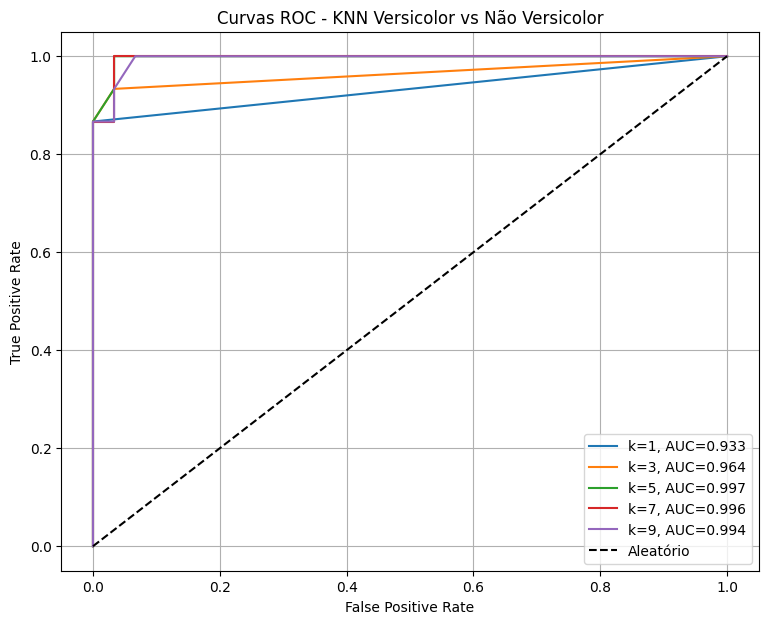

,k,AUC
0,1,0.933333
1,3,0.964444
2,5,0.996667
3,7,0.995556
4,9,0.994444


In [ ]:
# Curvas ROC para diferentes valores de k

ks = [1, 3, 5, 7, 9]
auc_resultados_e = []

plt.figure(figsize=(9, 7))

for k in ks:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_e_scaled, y_train_e)

    probas = modelo.predict_proba(X_test_e_scaled)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test_e, probas)
    valor_auc = auc(fpr, tpr)

    auc_resultados_e.append({
        "k": k,
        "AUC": valor_auc
    })

    plt.plot(fpr, tpr, label=f"k={k}, AUC={valor_auc:.3f}")

plt.plot([0, 1], [0, 1], "k--", label="Aleatório")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - KNN Versicolor vs Não Versicolor")
plt.legend()
plt.fill_between(fpr, tpr, alpha=0.1)
plt.grid(True)
plt.show()

display(pd.DataFrame(auc_resultados_e))

**Explicação da célula anterior**

- `ks`: lista os valores de k pedidos.
- `KNeighborsClassifier(n_neighbors=k)`: cria o KNN com o k atual.
- `fit()`: treina o modelo.
- `predict_proba()`: retorna probabilidades.
- `roc_curve()`: calcula pontos da curva ROC.
- `auc()`: calcula a área sob a curva.
- `plt.plot()`: desenha cada curva no mesmo gráfico.





### E - Análise dos resultados e conclusão

Valores pequenos de k, como k=1, tendem a ter baixa tendência de erro sistemático, mas maior variância. Isso significa que o modelo pode se ajustar demais aos detalhes do treino.

Valores maiores de k suavizam a decisão, reduzindo a variância, mas podendo aumentar o bias. Em geral, k intermediário costuma equilibrar melhor os dois efeitos.

A curva ROC mostra o desempenho em diferentes thresholds, e a AUC resume essa capacidade de separação. Quanto mais próxima de 1, melhor.

Conclusão da parte E: o KNN consegue separar versicolor de não versicolor usando apenas duas features. A análise de diferentes valores de k mostra o impacto entre bias e variance.

## F - Curva ROC

![Slide 33](slides_comandos/slide_033.png)

![Slide 34](slides_comandos/slide_034.png)

![Slide 35](slides_comandos/slide_035.png)

## F - Solução

Nesta parte será usada Logistic Regression para classificar ratos como obesos ou não obesos a partir do peso.

Dados:

- Não obesos: 450, 455, 570, 660
- Obesos: 575, 665, 700, 710

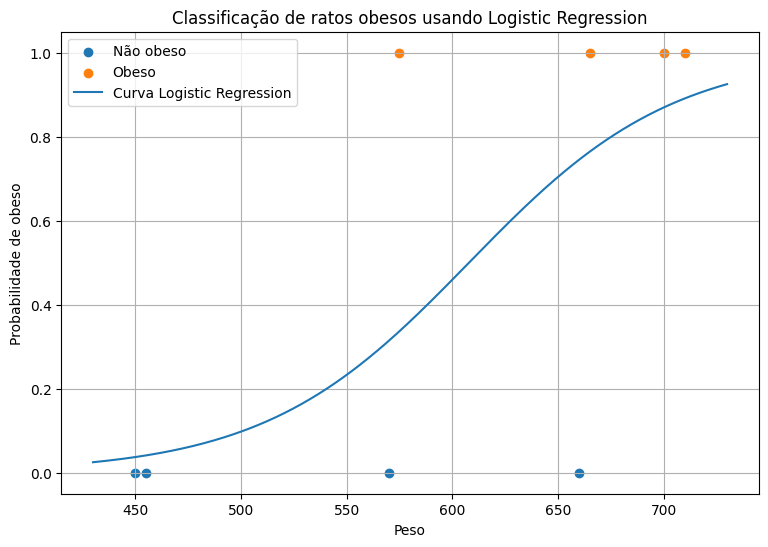

In [17]:
# Dados dos ratos e treinamento da Logistic Regression

pesos_nao_obesos = np.array([450, 455, 570, 660])
pesos_obesos = np.array([575, 665, 700, 710])

X_ratos = np.concatenate([pesos_nao_obesos, pesos_obesos]).reshape(-1, 1)
y_ratos = np.array([0, 0, 0, 0, 1, 1, 1, 1])

modelo_ratos = LogisticRegression()
modelo_ratos.fit(X_ratos, y_ratos)

x_grid = np.linspace(430, 730, 300).reshape(-1, 1)
probs_grid = modelo_ratos.predict_proba(x_grid)[:, 1]

plt.figure(figsize=(9, 6))
plt.scatter(pesos_nao_obesos, [0]*len(pesos_nao_obesos), label="Não obeso")
plt.scatter(pesos_obesos, [1]*len(pesos_obesos), label="Obeso")
plt.plot(x_grid, probs_grid, label="Curva Logistic Regression")
plt.xlabel("Peso")
plt.ylabel("Probabilidade de obeso")
plt.title("Classificação de ratos obesos usando Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

**Explicação da célula anterior**

- `np.array()`: cria vetores com os pesos.
- `np.concatenate()`: junta os pesos em um único vetor.
- `reshape(-1, 1)`: coloca os dados no formato esperado pelo scikit-learn.
- `LogisticRegression()`: cria o modelo.
- `fit()`: treina a regressão logística.
- `predict_proba()`: calcula a probabilidade de obesidade.
- `scatter()`: plota as amostras.
- `plot()`: plota a curva logística.


,threshold,TN,FP,FN,TP,FPR,TPR
0,1.010000,4,0,4,0,0.00,0.00
1,0.891219,4,0,3,1,0.00,0.25
2,0.869585,4,0,2,2,0.00,0.50
3,0.764311,4,0,1,3,0.00,0.75
4,0.745259,3,1,1,3,0.25,0.75
5,0.336905,3,1,0,4,0.25,1.00
6,0.314300,2,2,0,4,0.50,1.00
7,0.041148,1,3,0,4,0.75,1.00
8,0.037272,0,4,0,4,1.00,1.00
9,-0.010000,0,4,0,4,1.00,1.00


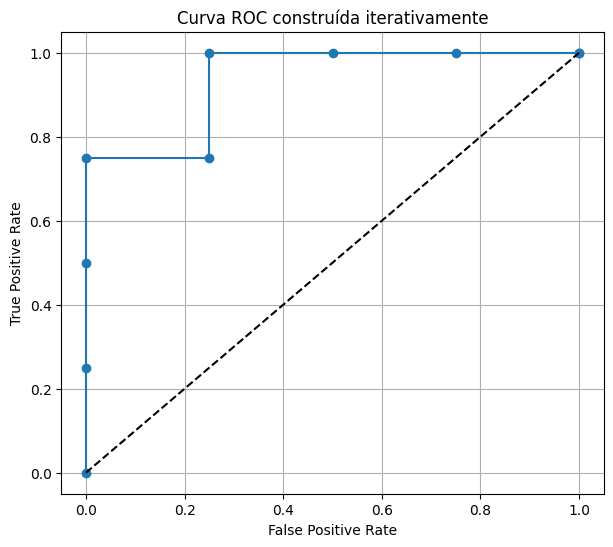

In [18]:
# Construção iterativa da curva ROC

probs_ratos = modelo_ratos.predict_proba(X_ratos)[:, 1]

thresholds = sorted(set(probs_ratos), reverse=True)
thresholds = [1.01] + thresholds + [-0.01]

linhas_roc = []

for threshold in thresholds:
    y_pred = (probs_ratos >= threshold).astype(int)
    cm = confusion_matrix(y_ratos, y_pred, labels=[0, 1])

    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    linhas_roc.append({
        "threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fpr,
        "TPR": tpr
    })

tabela_roc_manual = pd.DataFrame(linhas_roc)
display(tabela_roc_manual)

plt.figure(figsize=(7, 6))
plt.plot(tabela_roc_manual["FPR"], tabela_roc_manual["TPR"], marker="o")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC construída iterativamente")
plt.grid(True)
plt.show()

**Explicação da célula anterior**

- `probs_ratos`: probabilidades previstas para cada rato.
- `thresholds`: lista de pontos de corte testados.
- `(probs_ratos >= threshold)`: transforma probabilidade em classe.
- `confusion_matrix()`: calcula matriz de confusão para cada threshold.
- `TPR`: taxa de verdadeiros positivos.
- `FPR`: taxa de falsos positivos.
- `pd.DataFrame()`: organiza a tabela da construção da ROC.
- `plt.plot()`: desenha a curva ROC ponto a ponto.



### F - Análise dos resultados e conclusão

A Logistic Regression gera uma probabilidade contínua de obesidade. A curva ROC é construída testando vários thresholds.

Cada threshold gera uma matriz de confusão diferente. A partir dela são calculados TPR e FPR. Esses pares formam os pontos da curva ROC.

Conclusão da parte F: a curva ROC mostra como o classificador se comporta quando o ponto de corte muda. Isso é melhor do que avaliar apenas uma decisão fixa.

## G - Naive Bayes and Spam


![Slide 36](slides_comandos/slide_036.png)

![Slide 37](slides_comandos/slide_037.png)

![Slide 38](slides_comandos/slide_038.png)

## G - Solução




![Naive Bayes slide 55](slides_naive_bayes/naive_bayes_slide_055.png)

![Naive Bayes slide 56](slides_naive_bayes/naive_bayes_slide_056.png)

![Naive Bayes slide 70](slides_naive_bayes/naive_bayes_slide_070.png)

In [19]:
# Tabela de contagens inspirada no exemplo dos slides

contagens_palavras = pd.DataFrame({
    "Palavra": ["Dear", "Friend", "Lunch", "Money"],
    "Normal": [8, 5, 3, 1],
    "Spam": [2, 1, 0, 9]
})

contagens_palavras["Total_Normal"] = contagens_palavras["Normal"].sum()
contagens_palavras["Total_Spam"] = contagens_palavras["Spam"].sum()

display(contagens_palavras)

,Palavra,Normal,Spam,Total_Normal,Total_Spam
0,Dear,8,2,17,12
1,Friend,5,1,17,12
2,Lunch,3,0,17,12
3,Money,1,9,17,12


**Explicação da célula anterior**

- `pd.DataFrame()`: cria uma tabela manual com as contagens.
- `Palavra`: vocabulário usado no exemplo.
- `Normal`: quantidade de vezes que cada palavra aparece em mensagens normais.
- `Spam`: quantidade de vezes que cada palavra aparece em spam.
- `sum()`: calcula o total de palavras por classe.




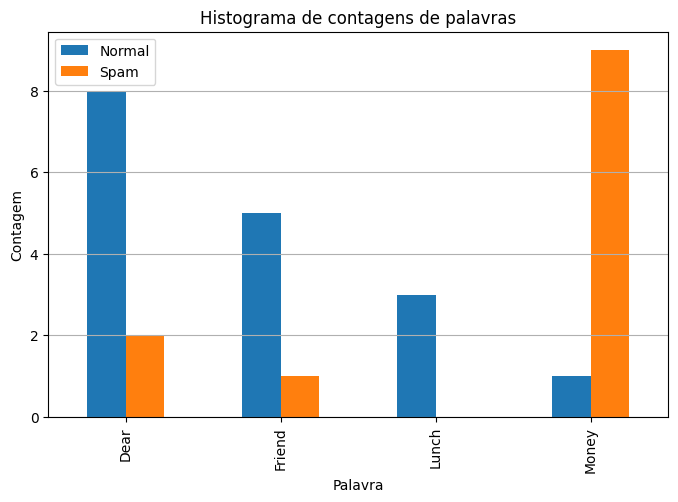

In [20]:
# Histogramas das palavras por classe

contagens_palavras.set_index("Palavra")[["Normal", "Spam"]].plot(kind="bar", figsize=(8, 5))
plt.title("Histograma de contagens de palavras")
plt.xlabel("Palavra")
plt.ylabel("Contagem")
plt.grid(axis="y")
plt.show()

**Explicação da célula anterior**

- `set_index("Palavra")`: usa as palavras como rótulo do eixo x.
- `plot(kind="bar")`: cria um gráfico de barras.
- `figsize`: define o tamanho do gráfico.
- `plt.title()`, `plt.xlabel()` e `plt.ylabel()`: configuram título e eixos.





In [21]:
# Cálculo das probabilidades com suavização de Laplace

vocabulario = contagens_palavras["Palavra"].tolist()
V = len(vocabulario)

total_normal = contagens_palavras["Normal"].sum()
total_spam = contagens_palavras["Spam"].sum()

prior_normal = 0.5
prior_spam = 0.5

probabilidades = contagens_palavras[["Palavra"]].copy()
probabilidades["P(palavra|Normal)"] = (contagens_palavras["Normal"] + 1) / (total_normal + V)
probabilidades["P(palavra|Spam)"] = (contagens_palavras["Spam"] + 1) / (total_spam + V)

display(probabilidades)

,Palavra,P(palavra|Normal),P(palavra|Spam)
0,Dear,0.428571,0.1875
1,Friend,0.285714,0.1250
2,Lunch,0.190476,0.0625
3,Money,0.095238,0.6250


**Explicação da célula anterior**

- `vocabulario`: lista com todas as palavras.
- `V`: tamanho do vocabulário.
- `prior_normal` e `prior_spam`: probabilidades iniciais das classes.
- `+ 1`: aplica suavização de Laplace.
- `total_normal + V`: ajusta o denominador para a suavização.
- `probabilidades`: tabela final com as probabilidades condicionais.





In [22]:
# Função de classificação de uma sequência de palavras

def classificar_mensagem_naive_bayes(palavras):
    score_normal = np.log(prior_normal)
    score_spam = np.log(prior_spam)

    detalhes = []

    for palavra in palavras:
        linha = probabilidades[probabilidades["Palavra"].str.lower() == palavra.lower()]

        if len(linha) == 0:
            continue

        p_normal = linha["P(palavra|Normal)"].iloc[0]
        p_spam = linha["P(palavra|Spam)"].iloc[0]

        score_normal += np.log(p_normal)
        score_spam += np.log(p_spam)

        detalhes.append({
            "Palavra": palavra,
            "P(palavra|Normal)": p_normal,
            "P(palavra|Spam)": p_spam
        })

    tabela_detalhes = pd.DataFrame(detalhes)

    resultado = pd.DataFrame({
        "Classe": ["Normal", "Spam"],
        "Score_log": [score_normal, score_spam]
    }).sort_values("Score_log", ascending=False)

    return resultado.iloc[0]["Classe"], resultado, tabela_detalhes

classe_prevista, tabela_scores, tabela_detalhes = classificar_mensagem_naive_bayes(["Dear", "Friend", "Money"])

display(tabela_detalhes)
display(tabela_scores)
print("Classificação:", classe_prevista)

,Palavra,P(palavra|Normal),P(palavra|Spam)
0,Dear,0.428571,0.1875
1,Friend,0.285714,0.1250
2,Money,0.095238,0.6250


,Classe,Score_log
1,Spam,-4.916569
0,Normal,-5.144583


Classificação: Spam


**Explicação da célula anterior**

- `classificar_mensagem_naive_bayes()`: função que recebe uma lista de palavras.
- `np.log()`: usa logaritmos para evitar produtos muito pequenos.
- `for palavra in palavras`: percorre cada palavra da mensagem.
- `str.lower()`: compara palavras sem diferenciar maiúsculas e minúsculas.
- `iloc[0]`: pega o valor da probabilidade na tabela.
- `score_normal` e `score_spam`: acumulam as probabilidades em log.
- `pd.DataFrame()`: organiza os resultados em tabelas.
- `sort_values()`: coloca a classe com maior score no topo.





### G - Análise dos resultados e conclusão

O Naive Bayes calcula a chance de uma mensagem pertencer a cada classe multiplicando as probabilidades condicionais das palavras. Como os produtos podem ficar muito pequenos, o cálculo foi feito com logaritmos.

A palavra `Money` aparece muito mais em spam do que em mensagens normais. Por isso, quando uma sequência contém essa palavra, o score de spam pode aumentar bastante.

A suavização de Laplace evita que uma palavra com contagem zero anule completamente a probabilidade de uma classe.

**Conclusão da parte G:** o Naive Bayes Multinomial é adequado para classificação textual simples, pois usa contagens de palavras para calcular probabilidades e tomar uma decisão.

## H - Gaussian Naive Bayes dos slides


![Slide 39](slides_comandos/slide_039.png)

![Slide 40](slides_comandos/slide_040.png)

![Slide 41](slides_comandos/slide_041.png)

## H - Solução




![Gaussian NB slide 8](slides_gaussian_naive_bayes/gaussian_nb_slide_008.png)

![Gaussian NB slide 9](slides_gaussian_naive_bayes/gaussian_nb_slide_009.png)

![Gaussian NB slide 10](slides_gaussian_naive_bayes/gaussian_nb_slide_010.png)

![Gaussian NB slide 14](slides_gaussian_naive_bayes/gaussian_nb_slide_014.png)

![Gaussian NB slide 15](slides_gaussian_naive_bayes/gaussian_nb_slide_015.png)

In [23]:
# Tabelas das distribuições Gaussianas do exemplo

distribuicoes_gnb = pd.DataFrame({
    "Classe": [
        "Loves Troll 2",
        "Loves Troll 2",
        "Loves Troll 2",
        "Does not Love Troll 2",
        "Does not Love Troll 2",
        "Does not Love Troll 2"
    ],
    "Feature": [
        "Popcorn (grams)",
        "Soda Pop (ml)",
        "Candy (grams)",
        "Popcorn (grams)",
        "Soda Pop (ml)",
        "Candy (grams)"
    ],
    "Media": [
        24,
        500,
        2,
        4,
        100,
        100
    ],
    "Desvio_Padrao": [
        4,
        100,
        1.6,
        2,
        150,
        20
    ]
})

display(distribuicoes_gnb)

,Classe,Feature,Media,Desvio_Padrao
0,Loves Troll 2,Popcorn (grams),24,4.0
1,Loves Troll 2,Soda Pop (ml),500,100.0
2,Loves Troll 2,Candy (grams),2,1.6
3,Does not Love Troll 2,Popcorn (grams),4,2.0
4,Does not Love Troll 2,Soda Pop (ml),100,150.0
5,Does not Love Troll 2,Candy (grams),100,20.0


**Explicação da célula anterior**

- `pd.DataFrame()`: cria a tabela das distribuições.
- `Classe`: indica se a pessoa ama ou não ama Troll 2.
- `Feature`: indica a variável analisada.
- `Media`: média da distribuição normal.
- `Desvio_Padrao`: desvio padrão da distribuição normal.





In [24]:
# Função da densidade Gaussiana e valores da nova pessoa

def gaussian_pdf(x, media, desvio):
    return (1 / (desvio * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - media) / desvio) ** 2)

nova_pessoa = {
    "Popcorn (grams)": 20,
    "Soda Pop (ml)": 500,
    "Candy (grams)": 25
}

display(pd.DataFrame([nova_pessoa]))

,Popcorn (grams),Soda Pop (ml),Candy (grams)
0,20,500,25


**Explicação da célula anterior**

- `gaussian_pdf()`: calcula a densidade da distribuição normal.
- `np.sqrt()`: calcula raiz quadrada.
- `np.exp()`: calcula a exponencial.
- `nova_pessoa`: representa o exemplo usado nos slides.
- `pd.DataFrame([nova_pessoa])`: exibe os valores em tabela.





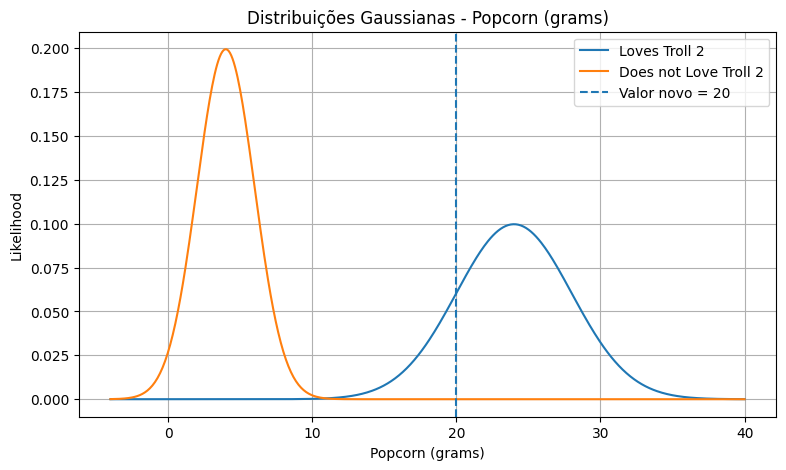

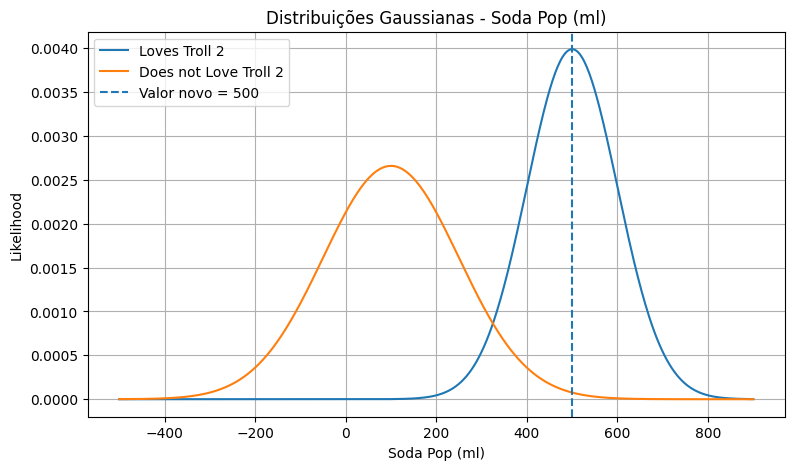

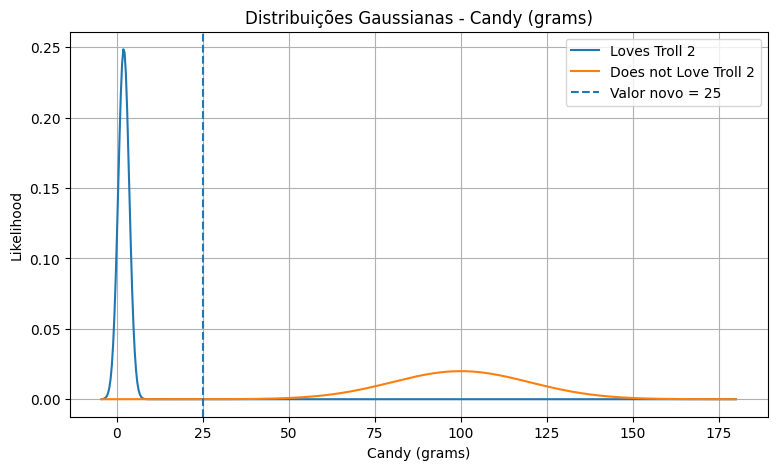

In [25]:
# Plot das distribuições Gaussianas

for feature in distribuicoes_gnb["Feature"].unique():
    plt.figure(figsize=(9, 5))

    dados_feature = distribuicoes_gnb[distribuicoes_gnb["Feature"] == feature]

    x_min = min(dados_feature["Media"] - 4 * dados_feature["Desvio_Padrao"])
    x_max = max(dados_feature["Media"] + 4 * dados_feature["Desvio_Padrao"])
    x_vals = np.linspace(x_min, x_max, 500)

    for _, linha in dados_feature.iterrows():
        y_vals = gaussian_pdf(x_vals, linha["Media"], linha["Desvio_Padrao"])
        plt.plot(x_vals, y_vals, label=linha["Classe"])

    plt.axvline(nova_pessoa[feature], linestyle="--", label=f"Valor novo = {nova_pessoa[feature]}")
    plt.title(f"Distribuições Gaussianas - {feature}")
    plt.xlabel(feature)
    plt.ylabel("Likelihood")
    plt.legend()
    plt.grid(True)
    plt.show()

**Explicação da célula anterior**

- `unique()`: pega cada feature uma vez.
- `np.linspace()`: cria valores para desenhar a curva.
- `iterrows()`: percorre as linhas da tabela.
- `gaussian_pdf()`: calcula os pontos da curva.
- `plt.axvline()`: marca o valor da nova pessoa.
- `plt.plot()`: desenha as distribuições.




In [26]:
# Likelihoods do exemplo dos slides e classificação

likelihoods_gnb = pd.DataFrame({
    "Classe": ["Loves Troll 2", "Does not Love Troll 2"],
    "Prior": [0.5, 0.5],
    "Likelihood Popcorn": [0.06, "tiny"],
    "Likelihood Soda Pop": [0.004, 0.000079],
    "Likelihood Candy": ["tiny", 0.02],
    "log(Prior)": [np.log(0.5), np.log(0.5)],
    "log(Likelihood Popcorn)": [np.log(0.06), -33.6],
    "log(Likelihood Soda Pop)": [np.log(0.004), np.log(0.000079)],
    "log(Likelihood Candy)": [-115, np.log(0.02)]
})

likelihoods_gnb["Score_log"] = (
    likelihoods_gnb["log(Prior)"] +
    likelihoods_gnb["log(Likelihood Popcorn)"] +
    likelihoods_gnb["log(Likelihood Soda Pop)"] +
    likelihoods_gnb["log(Likelihood Candy)"]
)

display(likelihoods_gnb)

classe_final = likelihoods_gnb.sort_values("Score_log", ascending=False).iloc[0]["Classe"]
print("Classificação final:", classe_final)

,Classe,Prior,Likelihood Popcorn,Likelihood Soda Pop,Likelihood Candy,log(Prior),log(Likelihood Popcorn),log(Likelihood Soda Pop),log(Likelihood Candy),Score_log
0,Loves Troll 2,0.5,0.06,0.004000,tiny,-0.693147,-2.813411,-5.521461,-115.000000,-124.028019
1,Does not Love Troll 2,0.5,tiny,0.000079,0.02,-0.693147,-33.600000,-9.446063,-3.912023,-47.651233


Classificação final: Does not Love Troll 2


**Explicação da célula anterior**

- `likelihoods_gnb`: tabela com os likelihoods usados no exemplo.
- `np.log()`: transforma multiplicações em somas.
- `Score_log`: soma do log do prior com os logs dos likelihoods.
- `sort_values()`: coloca o maior score no topo.
- `iloc[0]`: pega a classe vencedora.





In [27]:
# Função final pedida na questão

def classificar_troll2(popcorn, soda_pop, candy):
    scores = pd.DataFrame({
        "Classe": ["Loves Troll 2", "Does not Love Troll 2"],
        "Score_log": [
            np.log(0.5) + np.log(0.06) + np.log(0.004) + (-115),
            np.log(0.5) + (-33.6) + np.log(0.000079) + np.log(0.02)
        ]
    })

    scores = scores.sort_values("Score_log", ascending=False)
    return scores.iloc[0]["Classe"], scores

predicao_h, scores_h = classificar_troll2(20, 500, 25)

display(scores_h)
print("Predição:", predicao_h)

,Classe,Score_log
1,Does not Love Troll 2,-47.651233
0,Loves Troll 2,-124.028019


Predição: Does not Love Troll 2


**Explicação da célula anterior**

- `classificar_troll2()`: função que recebe valores como no exemplo.
- `Score_log`: calcula a pontuação em log para cada classe.
- `sort_values()`: ordena os scores.
- `return`: devolve a classe prevista e a tabela de scores.




### H - Análise dos resultados e conclusão

A classificação final usa os likelihoods do exemplo dos slides. Para a classe **Loves Troll 2**, o likelihood de candy é extremamente pequeno. Isso derruba o score final da classe, mesmo que popcorn e soda pop pareçam compatíveis.

Para **Does not Love Troll 2**, o conjunto de likelihoods gera score maior. Como estamos trabalhando com logaritmos, o maior valor é o melhor. Assim, a classe prevista é **Does not Love Troll 2**.

**Conclusão da parte H:** o Gaussian Naive Bayes combina prior e likelihoods das features. A classe escolhida é aquela com maior score probabilístico.

## I - Naive Bayes and Iris dataset / Acurácia


![Slide 42](slides_comandos/slide_042.png)

![Slide 43](slides_comandos/slide_043.png)

![Slide 44](slides_comandos/slide_044.png)

## I - Solução


In [28]:
# Treinamento do Gaussian Naive Bayes no Iris

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris,
    y_iris,
    test_size=0.30,
    random_state=42,
    stratify=y_iris
)

modelo_i = GaussianNB()
modelo_i.fit(X_train_i, y_train_i)

pred_i = modelo_i.predict(X_test_i)

acuracia_i = accuracy_score(y_test_i, pred_i)

print("Acurácia:", acuracia_i)
print()
print(classification_report(y_test_i, pred_i))

Acurácia: 0.9111111111111111

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45



**Explicação da célula anterior**

- `train_test_split()`: divide o Iris em treino e teste.
- `GaussianNB()`: cria o modelo Naive Bayes Gaussiano.
- `fit()`: treina o modelo.
- `predict()`: faz previsões no teste.
- `accuracy_score()`: calcula a acurácia.
- `classification_report()`: mostra precision, recall e F1-score.





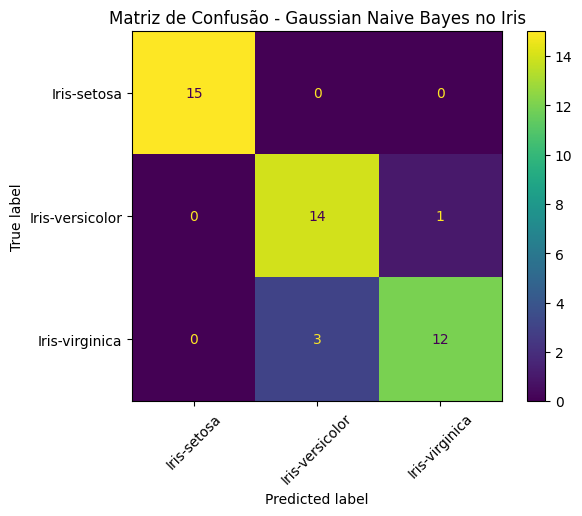

In [29]:
# Matriz de confusão do Naive Bayes no Iris

cm_i = confusion_matrix(y_test_i, pred_i, labels=modelo_i.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=modelo_i.classes_)
disp.plot(values_format="d")
plt.xticks(rotation=45)
plt.title("Matriz de Confusão - Gaussian Naive Bayes no Iris")
plt.show()

**Explicação da célula anterior**

- `confusion_matrix()`: calcula onde o modelo acertou e errou.
- `modelo_i.classes_`: mantém a ordem das classes.
- `ConfusionMatrixDisplay()`: prepara a visualização.
- `disp.plot()`: desenha a matriz.
- `plt.xticks(rotation=45)`: melhora a leitura dos nomes das classes.



### I - Análise dos resultados e conclusão

A acurácia mostra a proporção geral de acertos do modelo. No Iris, o Gaussian Naive Bayes costuma ter bom desempenho porque as classes possuem padrões bem definidos nas medidas de pétalas e sépalas.

O `classification_report` complementa a acurácia mostrando precision, recall e F1-score por classe. Isso é importante porque a acurácia sozinha pode esconder erros específicos em uma classe.

A matriz de confusão mostra visualmente quais espécies foram confundidas. Normalmente, `Iris-setosa` é mais fácil de separar, enquanto `Iris-versicolor` e `Iris-virginica` podem ter alguma sobreposição.

**Conclusão da parte I:** o Naive Bayes é simples, rápido e eficiente no Iris. A acurácia é útil como visão geral, mas deve ser analisada junto com precision, recall, F1-score e matriz de confusão.